In [1]:
import sys, os, time, math, random
import multiprocessing
import numba
from numba import njit,prange
from joblib import Parallel, delayed


In [2]:
import numpy as np

Monte Carlo simulations

In [3]:
#Base
# code adapted from https://www.geeksforgeeks.org/artificial-intelligence/what-is-monte-carlo-simulation/
def monte_carlo_pi(n_samples):
    inside = 0
    c = 0
    while c < n_samples:
        x = random.uniform(-1,1)
        y = random.uniform(-1,1)
        if x*x + y*y <= 1:
            inside += 1
        c += 1
    return 4 * (inside / n_samples)

def monte_carlo_pi_np(n_samples):
    x = np.random.uniform(-1,1,n_samples)
    y = np.random.uniform(-1,1,n_samples)
    inside = np.sum(x*x+y*y <= 1)

    return 4 * (inside / n_samples)
    

In [4]:
#Numba

@njit(nogil=True, parallel=True)
def monte_carlo_pi_numba(n_samples):
    inside = 0
    for i in prange(n_samples):
        x = np.random.uniform(-1,1)
        y = np.random.uniform(-1,1)

        if x*x + y*y <= 1:
            inside += 1
    return 4 * (inside/n_samples)

monte_carlo_pi_numba(10000)

3.2004

In [5]:
%load_ext Cython

In [6]:
%%cython --compile-args=-fopenmp --link-args=-fopenmp

from cython.parallel import prange
from libc.stdlib cimport rand, RAND_MAX
import cython

cdef extern from "stdlib.h" nogil:
    int rand_r(unsigned int *seed)

cdef extern from "omp.h" nogil:
    int omp_get_thread_num()

def monte_carlo_pi_cython(long n_samples,int n_threads):
    cdef long i
    cdef int inside = 0
    cdef double x, y 
    cdef unsigned int seed
    for i in prange(n_samples, num_threads=n_threads, schedule='static', nogil=True):
        myseed = omp_get_thread_num() + 1 + i
        x = (<double>rand_r(&seed) / RAND_MAX) * 2 - 1
        y = (<double>rand_r(&seed) / RAND_MAX) * 2 - 1

        if x*x + y*y <= 1:
            inside += 1
    return 4 * inside / n_samples

In [7]:
#Joblib


def chunk_worker_j(n, seed):
    np.random.seed(seed)
    x = np.random.uniform(-1,1,n)
    y = np.random.uniform(-1,1,n)
    return np.sum(x*x + y*y <= 1)

def monte_carlo_pi_joblib(n_samples, n_jobs):
    chunk = n_samples // n_jobs
    inside = Parallel(n_jobs=n_jobs)(
        delayed(chunk_worker_j)(chunk,seed) for seed in range(n_jobs)
    )
    return 4 * sum(inside) / (chunk * n_jobs)

In [8]:
#multiprocessing

def chunk_worker_m(args):# a helper function is needed to split the work into chunks, that can later run as separate processes
    n, seed = args
    np.random.seed(seed)
    x = np.random.uniform(-1,1,n)
    y = np.random.uniform(-1,1,n)
    return np.sum(x*x + y*y <= 1)

def monte_carlo_pi_multip(n_samples, n_procs):
    chunk = n_samples // n_procs
    with multiprocessing.Pool(n_procs) as pool:
        inside = pool.map(chunk_worker_m,[(chunk,seed) for seed in range(n_procs)])

    return 4 * sum(inside) / (chunk * n_procs)

Benchmark setup

In [9]:
numba.set_num_threads(4)

432 μs ± 4.59 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
34.3 μs ± 8.46 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
80.5 μs ± 5.71 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
19 μs ± 2.45 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 4.35 times longer than the fastest. This could mean that an intermediate result is being cached.
16.3 ms ± 12.6 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
69 ms ± 1.72 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.06 ms ± 99.3 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
160 μs ± 9.33 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
470 μs ± 116 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
41.4 μs ± 29.6 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
10.9 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
73.2 ms ± 3.07 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
41.6 ms ± 1.09 ms per loop (mean ± std.

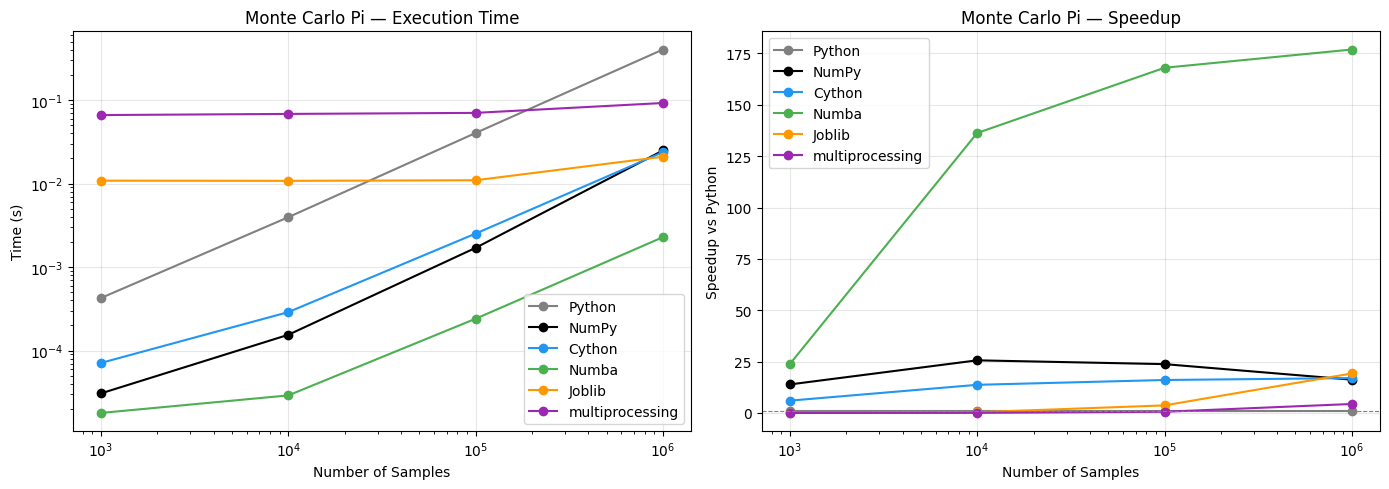

In [10]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 monte_carlo_pi(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_cython(n, 4)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_joblib(n, 4)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_multip(n, 4)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Monte Carlo Pi — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Monte Carlo Pi — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_results_4.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
numba.set_num_threads(8)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 monte_carlo_pi(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_cython(n, 8)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_joblib(n, 8)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_multip(n, 8)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Monte Carlo Pi — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Monte Carlo Pi — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_results_8.png', dpi=150, bbox_inches='tight')
plt.show()

409 μs ± 39.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
33.7 μs ± 6.2 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
162 μs ± 23.4 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 8.75 times longer than the fastest. This could mean that an intermediate result is being cached.
28.8 μs ± 36.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
25.9 ms ± 7.34 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
280 ms ± 4.6 ms per loop (mean ± std. dev. of 7 runs, 20 loops each)
4.43 ms ± 287 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
189 μs ± 22.3 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
370 μs ± 63.6 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
The slowest run took 4.22 times longer than the fastest. This could mean that an intermediate result is being cached.
48.7 μs ± 35.7 μs per loop (mean ± std. dev. of 7 runs, 20 loops each)
22.8 ms ± 2.18 ms per loop (mean ± std. dev. of 7 runs, 20 loo

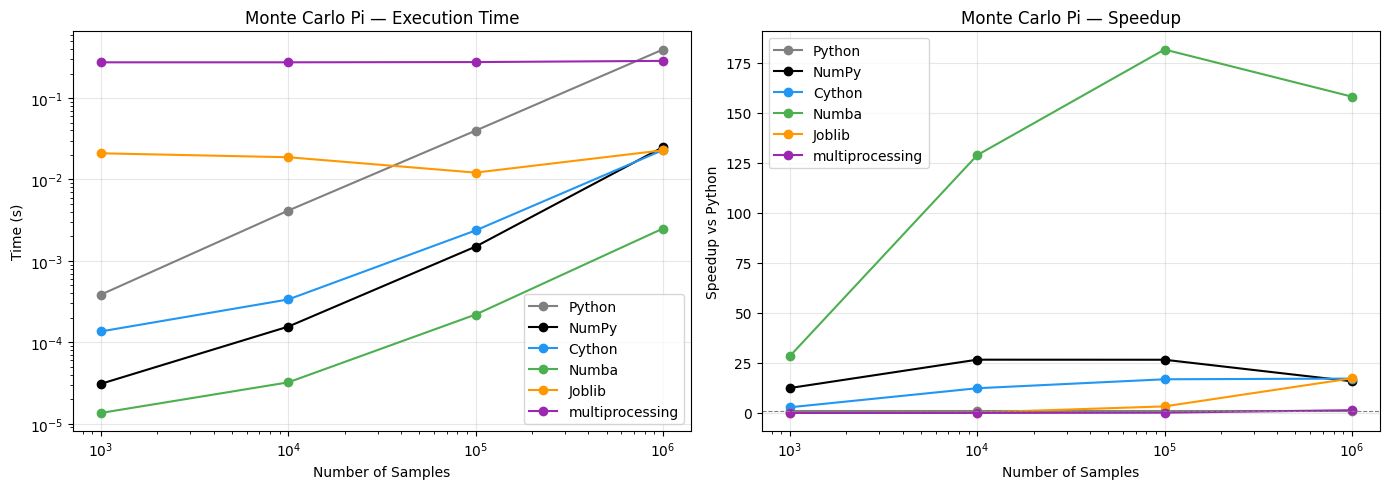

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [1000, 10000,100000,1000000]
libraries = ['Python', 'NumPy', 'Cython', 'Numba', 'Joblib', 'multiprocessing']
results = {lib: [] for lib in libraries}

for n in sizes:
    t = %timeit -o -n 20 monte_carlo_pi(n)
    results['Python'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_np(n)
    results['NumPy'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_cython(n, 16)
    results['Cython'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_numba(n)
    results['Numba'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_joblib(n, 16)
    results['Joblib'].append(t.best)
    
    t = %timeit -o -n 20 monte_carlo_pi_multip(n, 16)
    results['multiprocessing'].append(t.best)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'black', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Left: execution time
for lib, color in zip(libraries, colors):
    axes[0].loglog(sizes, results[lib], marker='o', label=lib, color=color)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Monte Carlo Pi — Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: speedup vs Python
baseline = results['Python']
for lib, color in zip(libraries, colors):
    speedup = [baseline[i] / results[lib][i] for i in range(len(sizes))]
    axes[1].semilogx(sizes, speedup, marker='o', label=lib, color=color)
axes[1].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xlabel('Number of Samples')
axes[1].set_ylabel('Speedup vs Python')
axes[1].set_title('Monte Carlo Pi — Speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_results_16.png', dpi=150, bbox_inches='tight')
plt.show()